In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. DATA LOADING & PREPROCESSING ---
# Loading the dataset from the specified path
df_raw = pd.read_csv('../raw_data/train.csv')

def preprocess_marathon_data(df):
    """
    Applies ordinal mapping and manual one-hot encoding
    based on the baseline notebook logic.
    """
    df_clean = df.copy()

    # Ordinal Mapping
    training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
    course_map   = {"Flat": 1, "Mixed": 2, "Hilly": 3}
    injury_map   = {"Minor": 1, "Moderate": 2, "Severe": 3}

    df_clean['training_program']  = df_clean['training_program'].map(training_map)
    df_clean['course_difficulty'] = df_clean['course_difficulty'].map(course_map)
    df_clean['injury_severity']   = df_clean['injury_severity'].map(injury_map).fillna(0)

    # Manual One-Hot Encoding for specific columns
    weather_dummies = pd.get_dummies(df_clean['marathon_weather'], prefix='marathon_weather')

    # Dropping 'Sunny' to match the baseline feature set (drop='first' logic)
    if 'marathon_weather_Sunny' in weather_dummies.columns:
        weather_dummies = weather_dummies.drop(columns=['marathon_weather_Sunny'])

    df_clean = pd.concat([df_clean.drop(columns=['marathon_weather']), weather_dummies], axis=1)

    # Filter out DNFs (Did Not Finish) where target is NaN
    df_clean = df_clean[df_clean['actual_finish_time_minutes'].notna()]

    return df_clean

df_processed = preprocess_marathon_data(df_raw)

# --- 2. FEATURE SELECTION ---

# Baseline Features (The original 14 features from your notebook)
baseline_features = [
    'age', 'running_experience_months', 'weekly_mileage_km', 'resting_heart_rate_bpm',
    'vo2_max', 'recovery_score', 'injury_count', 'injury_severity',
    'run_club_attendance_rate', 'course_difficulty', 'marathon_weather_Cold',
    'marathon_weather_Hot', 'marathon_weather_Rainy', 'marathon_weather_Windy'
]

# Expert Features (Baseline + Experience indicator)
expert_features = baseline_features + ['personal_best_minutes']

target = 'actual_finish_time_minutes'

# --- 3. MODEL HYPERPARAMETERS (XGBoost) ---
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'random_state': 42
}

# --- 4. PIPELINE TRAINING & EXPORT FUNCTION ---
def train_and_save_pipeline(features, model_name, data):
    print(f"\n>>> Starting Pipeline Training: {model_name}")

    X = data[features].copy()
    y = data[target]

    # Handling missing values with Median Imputation before Scaling
    # This maintains the distribution integrity for the scaler
    X = X.fillna(X.median(numeric_only=True))

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Building the Pipeline: Scaling -> Modeling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb_model', XGBRegressor(**xgb_params))
    ])

    # Fit the entire pipeline
    pipeline.fit(X_train, y_train)

    # Evaluation
    predictions = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"Metrics for {model_name}:")
    print(f"  - Mean Absolute Error: {mae:.2f} minutes")
    print(f"  - R2 Score: {r2:.4f}")

    # Exporting to joblib
    export_path = f"{model_name}.joblib"
    joblib.dump(pipeline, export_path)
    print(f"Successfully saved to: {export_path}")

# --- 5. EXECUTION ---

# Train & Export Baseline Pipeline
train_and_save_pipeline(baseline_features, 'marathon_pipeline', df_processed)

# Train & Export Expert Pipeline
train_and_save_pipeline(expert_features, 'marathon_expert_pipeline', df_processed)


>>> Starting Pipeline Training: marathon_pipeline
Metrics for marathon_pipeline:
  - Mean Absolute Error: 16.09 minutes
  - R2 Score: 0.6366
Successfully saved to: marathon_pipeline.joblib

>>> Starting Pipeline Training: marathon_expert_pipeline
Metrics for marathon_expert_pipeline:
  - Mean Absolute Error: 10.58 minutes
  - R2 Score: 0.8368
Successfully saved to: marathon_expert_pipeline.joblib


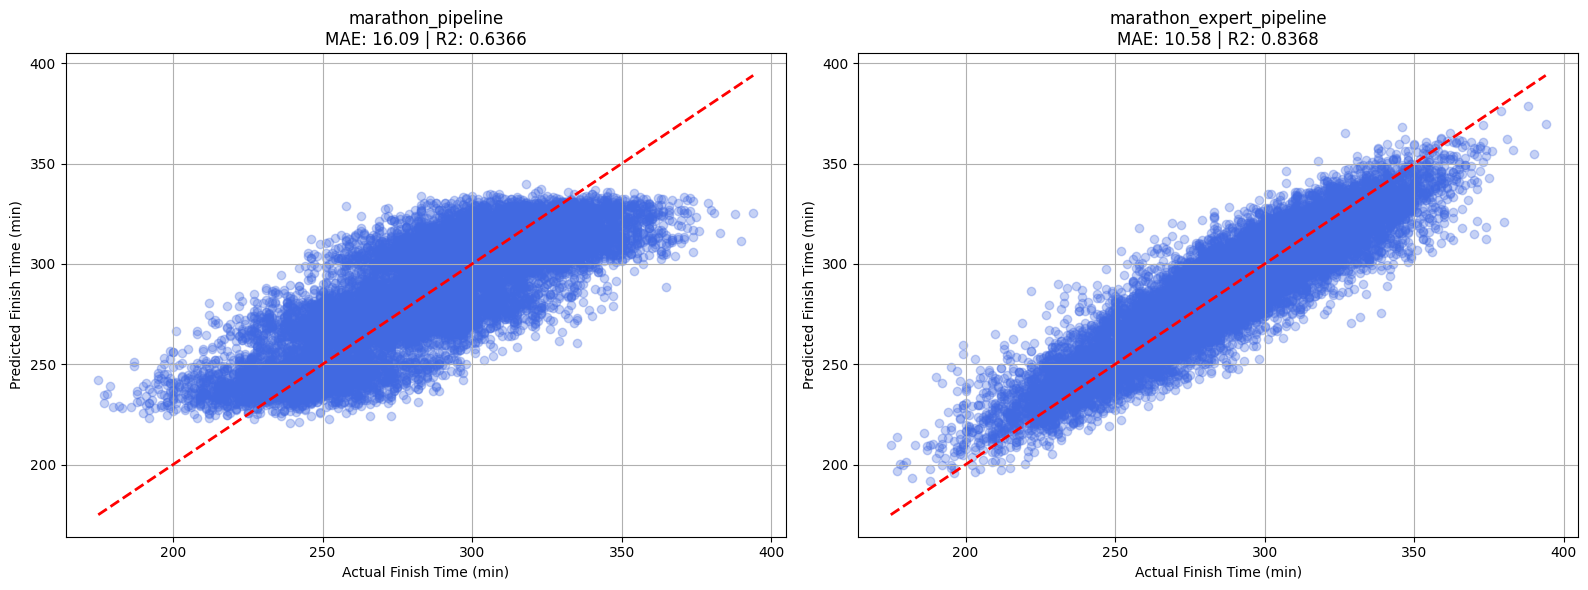


Final Model Comparison Table:
                   Model       MAE       R2
       marathon_pipeline 16.088219 0.636584
marathon_expert_pipeline 10.583079 0.836813


In [2]:
# --- 6. MODEL COMPARISON & VISUALIZATION ---
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(model_names, data):
    """
    Loads saved pipelines, makes predictions, and visualizes residuals.
    """
    results = []

    # Setting up the visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, name in enumerate(model_names):
        # Load the exported pipeline
        pipeline = joblib.load(f"{name}.joblib")

        # Determine features based on model name
        features = expert_features if "expert" in name else baseline_features

        X = data[features].copy()
        y = data[target]

        # Consistent Imputation
        X = X.fillna(X.median(numeric_only=True))

        # Splitting the same way as training for a fair test evaluation
        _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Predictions
        y_pred = pipeline.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results.append({"Model": name, "MAE": mae, "R2": r2})

        # Visualization: Actual vs Predicted
        axes[i].scatter(y_test, y_pred, alpha=0.3, color='royalblue')
        axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
        axes[i].set_title(f"{name}\nMAE: {mae:.2f} | R2: {r2:.4f}")
        axes[i].set_xlabel("Actual Finish Time (min)")
        axes[i].set_ylabel("Predicted Finish Time (min)")
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

    # Display results as a DataFrame
    results_df = pd.DataFrame(results)
    print("\nFinal Model Comparison Table:")
    print(results_df.to_string(index=False))

# Run the evaluation
evaluate_and_plot(['marathon_pipeline', 'marathon_expert_pipeline'], df_processed)

In [11]:
# --- 7. ROBUST FEATURE INSPECTION ---

def inspect_features(pipeline_name, original_feature_list):
    """
    Prints the feature importance by manually mapping names
    if the booster lost them during the Pipeline process.
    """
    # Load the pipeline
    pipeline = joblib.load(f"{pipeline_name}.joblib")

    # Access the XGBoost model from the pipeline
    model = pipeline.named_steps['xgb_model']

    # Get importance scores (these are always in the same order as your training list)
    importances = model.feature_importances_

    # Check if the booster has names
    booster_names = model.get_booster().feature_names

    # If booster names are missing, we use the list we provided during training
    if booster_names is None:
        print(f"\n[Note] {pipeline_name}: Booster names are hidden. Mapping from provided list...")
        feature_names = original_feature_list
    else:
        feature_names = booster_names

    # Create a Series for easy sorting
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    print(f"\n>>> Features in {pipeline_name}:")
    print(f"Total count: {len(feature_names)}")
    print(f"Top 5 Most Influential Features:")
    print(feat_imp.head(5))
    print("-" * 30)

# Run inspection with the lists we defined earlier
inspect_features('marathon_pipeline', baseline_features)
inspect_features('marathon_expert_pipeline', expert_features)


[Note] marathon_pipeline: Booster names are hidden. Mapping from provided list...

>>> Features in marathon_pipeline:
Total count: 14
Top 5 Most Influential Features:
running_experience_months    0.664559
injury_severity              0.130747
course_difficulty            0.037754
injury_count                 0.037019
resting_heart_rate_bpm       0.024067
dtype: float32
------------------------------

[Note] marathon_expert_pipeline: Booster names are hidden. Mapping from provided list...

>>> Features in marathon_expert_pipeline:
Total count: 15
Top 5 Most Influential Features:
running_experience_months    0.585968
personal_best_minutes        0.201503
injury_severity              0.052137
injury_count                 0.037297
course_difficulty            0.025630
dtype: float32
------------------------------


In [13]:
# --- GET EXACT COLUMN ORDER FOR API ---

# 1. Baseline Order
print("--- COPY THIS FOR COLUMNS_GENERAL ---")
print(baseline_features)

# 2. Expert Order
print("\n--- COPY THIS FOR COLUMNS_EXPERT ---")
print(expert_features)

--- COPY THIS FOR COLUMNS_GENERAL ---
['age', 'running_experience_months', 'weekly_mileage_km', 'resting_heart_rate_bpm', 'vo2_max', 'recovery_score', 'injury_count', 'injury_severity', 'run_club_attendance_rate', 'course_difficulty', 'marathon_weather_Cold', 'marathon_weather_Hot', 'marathon_weather_Rainy', 'marathon_weather_Windy']

--- COPY THIS FOR COLUMNS_EXPERT ---
['age', 'running_experience_months', 'weekly_mileage_km', 'resting_heart_rate_bpm', 'vo2_max', 'recovery_score', 'injury_count', 'injury_severity', 'run_club_attendance_rate', 'course_difficulty', 'marathon_weather_Cold', 'marathon_weather_Hot', 'marathon_weather_Rainy', 'marathon_weather_Windy', 'personal_best_minutes']
